Montando rede neural simples com tensorflow

In [ ]:
# importando tensorflow e outras libs
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#carregando datasets
print("---- CARREGANDO E VERIFICANDO DADOS --------")
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# formato da imagem
print("formato da imagem", x_train.shape)
print("formato do label", y_train.shape)
print("total de classes", len(np.unique(y_train)))

# preprocessamento
print("---- PREPROCESSAMENTO --------")
x_train = x_train/255.0
x_test = x_test/255.0

# Construir modelo MLP
print("---- CRIANDO MODELO --------")
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28,28)),
  tf.keras.layers.Dense(units=128, activation="relu"),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(units=10, activation="softmax")
])
# Sumario
model.summary()
# configurar otimizador
print("---- CONFIGURANDO OTIMIZADOR --------")
otimizador=tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=otimizador, loss="sparse_categorical_crossentropy", metrics=["accuracy"])



In [ ]:
# configurar parada
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)
# treinamento
print("---- TREINANDO O MODELO --------")
historico = model.fit(
    x_train,
    y_train,
    epochs=20 ,
    verbose=2,
    batch_size=32,
    validation_split=0.2, # Added validation split
    callbacks=[early_stopping]
    )

# Avaliação
print("---- AVALIANDO O MODELO --------")
loss_teste, acuraia_teste = model.evaluate(x_test, y_test, verbose=2)
print("Acuracia de teste: ", acuraia_teste)


## teste com nova imagem

In [ ]:
# testando imagem aleatória
import random
import matplotlib.pyplot as plt

indice = random.randint(0, len(x_test)-1)
imagem_soteada = x_test[indice]
label_sorteada = y_test[indice]

imagem_lote = np.expand_dims(imagem_soteada, axis=0)
probabilidades = model.predict(imagem_lote)
predicao = np.argmax(probabilidades)

plt.figure(figsize=(5, 5))
plt.imshow(imagem_soteada, cmap='gray')
plt.title(f'Label: {label_sorteada}, Predição: {predicao}')
plt.show()


## Cifar-10

In [ ]:
# importando tensorflow e outras libs
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:
# ==============================================================================
# PASSO 1: PREPARAÇÃO DOS DADOS
# ==============================================================================
print("Carregando e preparando os dados...")
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.cifar10.load_data()
# Nomes amigáveis para as 10 classes do CIFAR-10
nomes_classes = ['Avião', 'Carro', 'Pássaro', 'Gato', 'Cervo',
                 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']

# Normalização (transformar pixels de 0-255 para 0-1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# One-Hot Encoding (transforma o número 3 em [0,0,0,1,0,0,0,0,0,0])
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)

print("Formato dos dados de treinamento: ", train_images.shape)

In [ ]:
# ==============================================================================
# PASSO 2: CONSTRUÇÃO DA ARQUITETURA MLP
# ==============================================================================
print("Construindo o modelo MLP...")
modelo_mlp = tf.keras.models.Sequential([
    # O Flatten "destrói" a imagem geométrica e cria uma linha reta de 3072 pixels
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),

    # Camadas Ocultas (O "Cérebro" de força bruta)
    tf.keras.layers.Dense(128, activation='relu'),

    # Camada de Saída (10 classes)
    tf.keras.layers.Dense(10, activation='softmax')
])

modelo_mlp.summary()


In [ ]:
# ==============================================================================
# PASSO 3: COMPILAÇÃO E TREINAMENTO
# ==============================================================================
# Compilação usando CategoricalCrossentropy (pois usamos One-Hot Encoding)
modelo_mlp.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Configurando o EarlyStopping
parada_antecipada = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,                # Para se não melhorar por 3 épocas
    restore_best_weights=True  # Salva o melhor modelo histórico
)

print("\nIniciando o treinamento do MLP...")
historico_mlp = modelo_mlp.fit(
    train_images,
    train_labels,
    epochs=20,                 # Colocamos 20, mas o EarlyStopping pode parar antes
    validation_data=(test_images, test_labels),
    callbacks=[parada_antecipada]
)

In [ ]:
# ==============================================================================
# PASSO 4: RELATÓRIOS E VISUALIZAÇÕES
# ==============================================================================
print("\nGerando relatórios e gráficos...")

# 4.1 Gráficos de Treinamento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Acurácia
ax1.plot(historico_mlp.history['accuracy'], label='Treino', color='blue')
ax1.plot(historico_mlp.history['val_accuracy'], label='Validação', color='orange')
ax1.set_title('Evolução da Acurácia (MLP)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()

# Gráfico de Perda (Loss)
ax2.plot(historico_mlp.history['loss'], label='Treino', color='blue')
ax2.plot(historico_mlp.history['val_loss'], label='Validação', color='orange')
ax2.set_title('Evolução do Erro/Loss (MLP)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()
plt.show()

# 4.2 Relatório Estatístico (Scikit-Learn)
print("\nGerando previsões para a base de testes...")
todas_previsoes = modelo_mlp.predict(test_images)

# Convertendo de volta de probabilidades para números inteiros (0 a 9)
previsoes_classes = np.argmax(todas_previsoes, axis=1)
gabarito_classes = np.argmax(test_labels, axis=1)

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (MLP) ---")
print(classification_report(gabarito_classes, previsoes_classes, target_names=nomes_classes))

# 4.3 Matriz de Confusão
matriz = confusion_matrix(gabarito_classes, previsoes_classes)
fig, ax = plt.subplots(figsize=(10, 10))
display = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
display.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Matriz de Confusão - MLP (CIFAR-10)")
plt.show()


In [ ]:
# ==============================================================================
# PASSO 4: TESTE COM IMAGEM ALEATÓRIA
# ==============================================================================
indice = random.randint(0, len(test_images) - 1)
imagem_teste = test_images[indice]
label_real_num = gabarito_classes[indice] # Já convertemos para inteiro no passo 4.2
nome_real = nomes_classes[label_real_num]

# Formata a imagem para prever isoladamente
imagem_pronta = np.expand_dims(imagem_teste, axis=0)
previsao_individual = modelo_mlp.predict(imagem_pronta)

# Interpreta o resultado
indice_previsto = np.argmax(previsao_individual[0])
nome_previsto = nomes_classes[indice_previsto]
confianca = previsao_individual[0][indice_previsto] * 100

print("\n--- TESTE INDIVIDUAL (MLP) ---")
print(f"Objeto Real: {nome_real}")
print(f"Previsão da IA: {nome_previsto} (Certeza: {confianca:.2f}%)")

if nome_real == nome_previsto:
    print("STATUS: O Modelo ACERTOU! 🎉")
else:
    print("STATUS: O Modelo ERROU. ❌")

## Rede CNN

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Carregando os dados de Treino (para aprender) e Teste (para a prova final)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()



In [6]:
# aplicando one-hot
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=10)


In [7]:
# Normalização
train_images = train_images/255
test_images = test_images/255

# Nomes amigáveis para as 10 classes (pois os labels são apenas números de 0 a 9)
nomes_classes = ['Avião', 'Carro', 'Pássaro', 'Gato', 'Cervo',
                 'Cachorro', 'Sapo', 'Cavalo', 'Navio', 'Caminhão']

In [ ]:
train_images.shape

In [4]:
## EXTRAÇÃO DE CARACTERISTICAS
#coinstruindo modelo
modelo=tf.keras.models.Sequential()

# add 1º camada de convolução
modelo.add(
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation=tf.keras.activations.relu,
        input_shape=(32,32,3)
    )
)
# camada de compressão (pooling)
modelo.add(
    layers.MaxPooling2D(pool_size=(2,2))
)

# add 2º camada de convolução
modelo.add(
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation=tf.keras.activations.relu,
        input_shape=(32,32,3)
    )
)
# camada de compressão (pooling)
modelo.add(
    layers.MaxPooling2D(pool_size=(2,2))
)
## CLASSIFICAÇÃO
# Achatar
modelo.add(layers.Flatten())

# camadas ocultas
modelo.add(
    layers.Dense(
        units=64,
        activation=tf.keras.activations.relu
    )
)
#camada de saida
modelo.add(
    layers.Dense(
        units=10,
        activation=tf.keras.activations.softmax
    )
)
# mostrar o resumo do modelo
# modelo.summary()

# metricas
metricas_de_analise = [
    'accuracy',
    tf.keras.metrics.Precision(name='precisao'),
    tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acuracia'),
    tf.keras.metrics.Precision(name='precisao'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
    tf.keras.metrics.TruePositives(name='tp'),
    tf.keras.metrics.FalsePositives(name='fp'),
    tf.keras.metrics.TrueNegatives(name='tn'),
    tf.keras.metrics.FalseNegatives(name='fn'),
    tf.keras.metrics.CategoricalCrossentropy(name='cce')

]

# configurar otimizador
#otimizador=tf.keras.optimizers.Adam(learning_rate=0.001)
otimizador="adam"

# Compilar modelo
modelo.compile(
    optimizer=otimizador,
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=metricas_de_analise
)

# condição de parada
parada_antecipada=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Treino
historico=modelo.fit(
    train_images,
    train_labels,
    epochs=10,
    verbose=2,
    validation_data=(test_images, test_labels)
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 - 66s - 42ms/step - accuracy: 0.4814 - auc: 0.8783 - cce: 1.4470 - fn: 37181.0000 - fp: 5091.0000 - loss: 1.4470 - precisao: 0.7157 - precisao_1: 0.7157 - recall: 0.2564 - tn: 444909.0000 - top3_acuracia: 0.7911 - tp: 12819.0000 - val_accuracy: 0.5836 - val_auc: 0.9219 - val_cce: 1.1745 - val_fn: 5958.0000 - val_fp: 1478.0000 - val_loss: 1.1745 - val_precisao: 0.7322 - val_precisao_1: 0.7322 - val_recall: 0.4042 - val_tn: 88522.0000 - val_top3_acuracia: 0.8697 - val_tp: 4042.0000
Epoch 2/10
1563/1563 - 76s - 48ms/step - accuracy: 0.6184 - auc: 0.9318 - cce: 1.0943 - fn: 26873.0000 - fp: 7305.0000 - loss: 1.0943 - precisao: 0.7600 - precisao_1: 0.7600 - recall: 0.4625 - tn: 442695.0000 - top3_acuracia: 0.8821 - tp: 23127.0000 - val_accuracy: 0.6288 - val_auc: 0.9361 - val_cce: 1.0561 - val_fn: 4969.0000 - val_fp: 1737.0000 - val_loss: 1.0561 - val_precisao: 0.7434 - val_precisao_1: 0.7434 - val_recall: 0.5031 - val_tn: 88263.0000 - val_top3_acuracia: 0.8920 - val_tp

## Orverffitting

In [8]:
train_images_tiny = train_images[:500]
train_labels_tiny = train_labels[:500]

print(f"Treinando com apenas {len(train_images_tiny)} imagens...")

# 2. A REDE "GIGANTE" E train_images_tiny = train_images[:500]
train_labels_tiny = train_labels[:500]
modelo_overfit = models.Sequential([
    # Muitos filtros desde o início
    layers.Conv2D(128, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    # Um cérebro denso gigantesco e sem Dropout
    layers.Dense(1024, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 3. COMPILAÇÃO
modelo_overfit.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# 4. TREINAMENTO (Muitas épocas, sem Early Stopping)
print("Iniciando o treinamento (forçando o overfitting)...")
historico_overfit = modelo_overfit.fit(
    train_images_tiny,
    train_labels_tiny,
    epochs=50,
    # Continuamos testando nas 10.000 imagens originais para ver o desastre
    validation_data=(test_images, test_labels),
    verbose=1 # Mostra a barra de progresso
)

Treinando com apenas 500 imagens...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando o treinamento (forçando o overfitting)...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.1100 - loss: 2.3809 - val_accuracy: 0.1069 - val_loss: 2.2892
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.1620 - loss: 2.2261 - val_accuracy: 0.2222 - val_loss: 2.1302
Epoch 3/50
 5/16 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.2956 - loss: 2.0466

KeyboardInterrupt: 

## overffiting com tratamento


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando o treinamento do Modelo Tratado...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 321ms/step - accuracy: 0.0920 - loss: 2.3255 - val_accuracy: 0.1166 - val_loss: 2.2792
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 399ms/step - accuracy: 0.1460 - loss: 2.2493 - val_accuracy: 0.1948 - val_loss: 2.1944
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.1740 - loss: 2.1628 - val_accuracy: 0.1974 - val_loss: 2.1416
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step - accuracy: 0.1980 - loss: 2.1059 - val_accuracy: 0.2356 - val_loss: 2.0738
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 384ms/step - accuracy: 0.1640 - loss: 2.0921 - val_accuracy: 0.2722 - val_loss: 2.0412
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accuracy: 0.2240 - loss: 2.0504 - val_accuracy: 0.2679 - val_loss: 2.0075
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.2360 - loss: 2.0005 - val_accuracy: 0.2881 - val_loss: 1.9890
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 382ms/step - accu

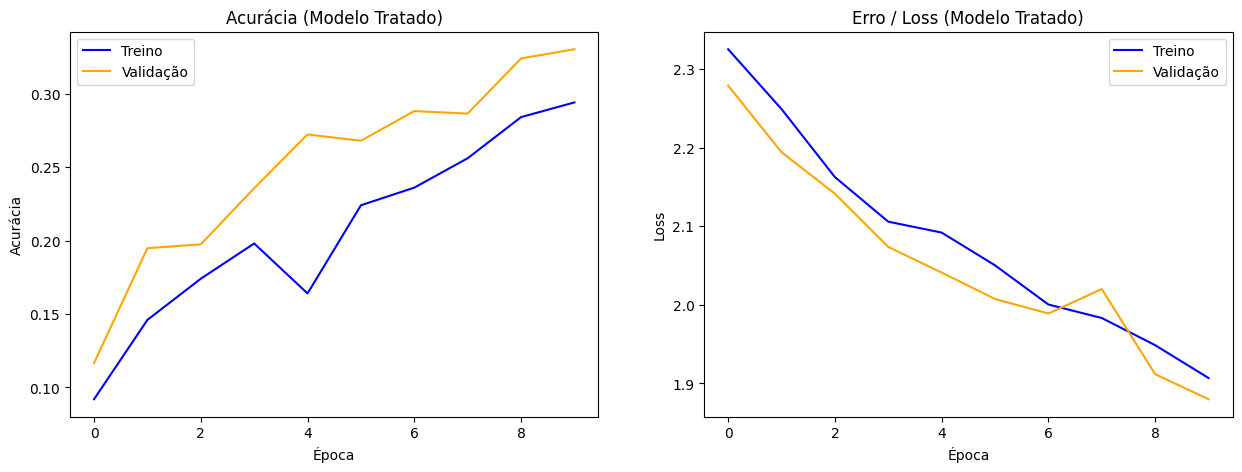

In [9]:
train_images_tiny = train_images[:500]
train_labels_tiny = train_labels[:500]
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ==============================================================================
# PASSO 1: PREPARAÇÃO DA AMOSTRA ESTRATIFICADA (500 IMAGENS)
# ==============================================================================
# Usamos exatamente a mesma amostragem estratificada para uma comparação justa
train_images_tiny, _, train_labels_tiny, _ = train_test_split(
    train_images,
    train_labels,
    train_size=500,
    stratify=train_labels,
    random_state=42
)

# ==============================================================================
# PASSO 2: ARQUITETURA OTIMIZADA COM TRATAMENTOS
# ==============================================================================
modelo_tratado = models.Sequential([
    # --------------------------------------------------------------------------
    # TRATAMENTO 1: DATA AUGMENTATION (Aumento de Dados)
    # Roda apenas durante o modelo.fit(). Gera variações das imagens em tempo real.
    # --------------------------------------------------------------------------
    layers.RandomFlip("horizontal", input_shape=(32, 32, 3)), # Espelha horizontalmente
    layers.RandomRotation(0.15),                              # Leve rotação (até 15%)
    layers.RandomZoom(0.1),                                   # Leve zoom (10%)

    # --------------------------------------------------------------------------
    # TRATAMENTO 2: REDUÇÃO DE COMPLEXIDADE
    # Trocamos os filtros gigantes (128/256/1024) por filtros adequados (32/64/128)
    # --------------------------------------------------------------------------
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # --------------------------------------------------------------------------
    # TRATAMENTO 3: DROPOUT
    # "Desliga" 40% dos neurônios aleatoriamente a cada época para evitar memorização
    # --------------------------------------------------------------------------
    layers.Dropout(0.4),

    # Camada de Saída (10 classes)
    layers.Dense(10, activation='softmax')
])

modelo_tratado.summary()

# ==============================================================================
# PASSO 3: COMPILAÇÃO E EARLY STOPPING
# ==============================================================================
modelo_tratado.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# ------------------------------------------------------------------------------
# TRATAMENTO 4: EARLY STOPPING (Parada Antecipada)
# Monitora val_loss. Se não melhorar em 5 épocas, interrompe e restaura o melhor estado.
# ------------------------------------------------------------------------------
parada_antecipada = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ==============================================================================
# PASSO 4: TREINAMENTO
# ==============================================================================
print("\nIniciando o treinamento do Modelo Tratado...")
historico_tratado = modelo_tratado.fit(
    train_images_tiny,
    train_labels_tiny,
    epochs=10, # Pedimos 50 épocas, mas o Early Stopping vai parar assim que estagnar
    validation_data=(test_images, test_labels),
    callbacks=[parada_antecipada]
)

# ==============================================================================
# PASSO 5: VISUALIZAÇÃO DA CURA DO OVERFITTING
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de Acurácia
ax1.plot(historico_tratado.history['accuracy'], label='Treino', color='blue')
ax1.plot(historico_tratado.history['val_accuracy'], label='Validação', color='orange')
ax1.set_title('Acurácia (Modelo Tratado)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Acurácia')
ax1.legend()

# Gráfico de Perda (Loss)
ax2.plot(historico_tratado.history['loss'], label='Treino', color='blue')
ax2.plot(historico_tratado.history['val_loss'], label='Validação', color='orange')
ax2.set_title('Erro / Loss (Modelo Tratado)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

# underfit

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# 1. A RECEITA DO UNDERFITTING
# ==========================================
modelo_underfit = models.Sequential([
    # Uma única camada convolucional minúscula (só 8 filtros)
    layers.Conv2D(8, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    # Um freio absurdo: Desligamos 80% dos neurônios a cada época!
    layers.Dropout(0.8),

    # Camada de saída
    layers.Dense(10, activation='softmax')
])

modelo_underfit.summary()

# ==========================================
# 2. COMPILAÇÃO E TREINAMENTO
# ==========================================
modelo_underfit.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\nIniciando o treinamento (forçando o underfitting)...")
historico_underfit = modelo_underfit.fit(
    train_images,
    train_labels,
    epochs=15,
    validation_data=(test_images, test_labels)
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        18,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,234 (71.23 KB)

 Trainable params: 18,234 (71.23 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando o treinamento (forçando o underfitting)...
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.3269 - loss: 1.8736 - val_accuracy: 0.4574 - val_loss: 1.5434
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4193 - loss: 1.6284 - val_accuracy: 0.4988 - val_loss: 1.4410
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4329 - loss: 1.5955 - val_accuracy: 0.5030 - val_loss: 1.4302
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4400 - loss: 1.5729 - val_accuracy: 0.5227 - val_loss: 1.3826
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.4472 - loss: 1.5596 - val_accuracy: 0.5274 - val_loss: 1.3793
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.4492 - loss: 1.5537 - val_accuracy: 0.5259 - val_loss: 1.3876
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.4547 - loss: 1.5393 - val_accuracy: 0.5299 - val_loss: 1.3520
Epoch 8/15
1563/1563 ━

## Under com trat


In [ ]:
# ==========================================
# 1. A CURA: AUMENTANDO A CAPACIDADE
# ==========================================
modelo_curado = models.Sequential([
    # Mais filtros para capturar padrões básicos (bordas, cores)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2, 2),

    # Segunda camada para formas intermediárias (rodas, orelhas)
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Terceira camada para formas complexas (focinhos, janelas)
    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    # Um "cérebro" denso mais capaz
    layers.Dense(128, activation='relu'),

    # Freio reduzido para um nível saudável (apenas 30%)
    layers.Dropout(0.3),

    # Camada de saída
    layers.Dense(10, activation='softmax')
])

# ==========================================
# 2. COMPILAÇÃO E TREINAMENTO
# ==========================================
modelo_curado.compile(
    optimizer='adam',
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\nIniciando o treinamento do modelo curado...")
historico_curado = modelo_curado.fit(
    train_images,
    train_labels,
    epochs=15,
    validation_data=(test_images, test_labels)
)